In [1]:
!git clone https://github.com/niaz1971/COTTON_LEAF_DISEASE_DATASET.git

Cloning into 'COTTON_LEAF_DISEASE_DATASET'...
remote: Enumerating objects: 220, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (71/71), done.
remote: Total 220 (delta 46), reused 11 (delta 11), pack-reused 138 (from 1)
Receiving objects: 100% (220/220), 237.89 MiB | 17.50 MiB/s, done.
Resolving deltas: 100% (85/85), done.
Updating files: 100% (37/37), done.


In [2]:
cd COTTON_LEAF_DISEASE_DATASET

/content/COTTON_LEAF_DISEASE_DATASET


In [3]:
!pip install lime kaggle
# Step 2: Set up Kaggle API for dataset download
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
# Step 3: Download and unzip malaria cell images dataset
!kaggle datasets download -d pantho12/sar-cld-2024-dataset-for-cotton-leaf
!unzip -q sar-cld-2024-dataset-for-cotton-leaf.zip
!rm sar-cld-2024-dataset-for-cotton-leaf.zip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=17b6efe34a279d8843f4080aa0ed86baa50b7c0f332807e890f12e8500a118c9
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime
Dataset URL: https://www.kaggle.com/datasets/pantho12/sar-cld-2024-dataset-for-cotton-leaf
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.46G/1.46G [00:18<00:00, 83.9MB/s]



In [4]:
!ls

 1_EFFICIENTNET.ipynb
 AZHAR_PAPER_MODELS_WITH_DIFFERENT_SEEDS
 EFFICIENTNET.ipynb
 INCEPTIONV3.ipynb
 kaggle.json
 MOBILENET.ipynb
 MODEL_SEND_BY_MUDASAR
 RESNET101.ipynb
 RESNET152.ipynb
 RESNET50.ipynb
'SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection'
 SHUFFLENET.ipynb
 VGG16.ipynb
 VGG19.ipynb
 XCEPTION.ipynb


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix
import warnings

# SUPPRESS ALL WARNINGS (simplest fix)
warnings.filterwarnings('ignore')

# Set random seeds
tf.random.set_seed(44)
np.random.seed(44)
print("✅ TensorFlow:", tf.__version__)

# =====================================================================
# UPDATED DATASET PATHS FOR SAR-CLD-2024
# =====================================================================
base_dataset_path = "SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection"

# Mapping to Augmented for training/validation, and Original for testing
augmented_path = os.path.join(base_dataset_path, "Augmented Dataset", "Augmented Dataset")
original_path = os.path.join(base_dataset_path, "Original Dataset", "Original Dataset")

# EfficientNetB0 default input size is 224x224
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ⚠️ IMPORTANT: EfficientNet handles rescaling internally. Do NOT use rescale=1./255
train_datagen = ImageDataGenerator(
    validation_split=0.2, # Splitting augmented data for training and validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator() # No rescaling here either

# Load datasets
train_generator = train_datagen.flow_from_directory(
    augmented_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    augmented_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    original_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
print(num_classes)

# =====================================================================
# EFFICIENTNET MODEL BUILDING
# =====================================================================
print("\n🏗️ Building EfficientNetB0 Model...")

# Load pre-trained EfficientNetB0 base without the top classification layer
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

# Freeze the base model layers (Fine-tune later if needed)
base_model.trainable = False

# Create the top architecture
inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x) # Helps prevent overfitting
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

✅ TensorFlow: 2.20.0
Found 5600 images belonging to 7 classes.
Found 1400 images belonging to 7 classes.
Found 2137 images belonging to 7 classes.
7

🏗️ Building EfficientNetB0 Model...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
# Dataset info
class_names = list(train_generator.class_indices.keys())
print(f"\n✅ Dataset loaded:")
print(f"Train: {train_generator.samples}, Val: {val_generator.samples}, Test: {test_generator.samples}")
print(f"Classes: {class_names}")


✅ Dataset loaded:
Train: 5600, Val: 1400, Test: 2137
Classes: ['Bacterial Blight', 'Curl Virus', 'Healthy Leaf', 'Herbicide Growth Damage', 'Leaf Hopper Jassids', 'Leaf Redding', 'Leaf Variegation']


In [7]:
# Model (EfficientNetB0)
def create_model(num_classes):
    # Load pre-trained EfficientNetB0 base
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze the base model weights
    base_model.trainable = False

    # Build the sequential architecture
    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.3),                 # EfficientNet benefits from slightly higher dropout
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),                 # Adjusted to balance regularization
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Initialize the model
model = create_model(len(class_names))

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # Slightly adjusted for a frozen EfficientNet
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\nModel ready!")

# Callbacks (Swapped extension to .keras as per modern Keras standards)
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=3, min_lr=1e-7),
    tf.keras.callbacks.ModelCheckpoint('best_cotton_model.keras', save_best_only=True, monitor='val_accuracy')
]

# TRAIN
print("\n🚀 Training starts NOW...")
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=30,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,442 (16.08 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


Model ready!

🚀 Training starts NOW...
Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 169s 722ms/step - accuracy: 0.5959 - loss: 1.1000 - val_accuracy: 0.6933 - val_loss: 0.9311 - learning_rate: 5.0000e-04
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 116s 665ms/step - accuracy: 0.7730 - loss: 0.6406 - val_accuracy: 0.7355 - val_loss: 0.7799 - learning_rate: 5.0000e-04
Epoch 3/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 118s 673ms/step - accuracy: 0.8132 - loss: 0.5275 - val_accuracy: 0.7427 - val_loss: 0.8048 - learning_rate: 5.0000e-04
Epoch 4/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 116s 666ms/step - accuracy: 0.8273 - loss: 0.4734 - val_accuracy: 0.7413 - val_loss: 0.8815 - learning_rate: 5.0000e-04
Epoch 5/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 116s 661ms/step - accuracy: 0.8479 - loss: 0.4340 - val_accuracy: 0.7355 - val_loss: 0.8375 - learning_rate: 5.0000e-04
Epoch 6/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 144s 673ms/step - accuracy: 0.8516 - loss: 0.4175 - val_accuracy: 0.7631 - val_loss: 0.7854 - learning_rate: 5.0000e-04


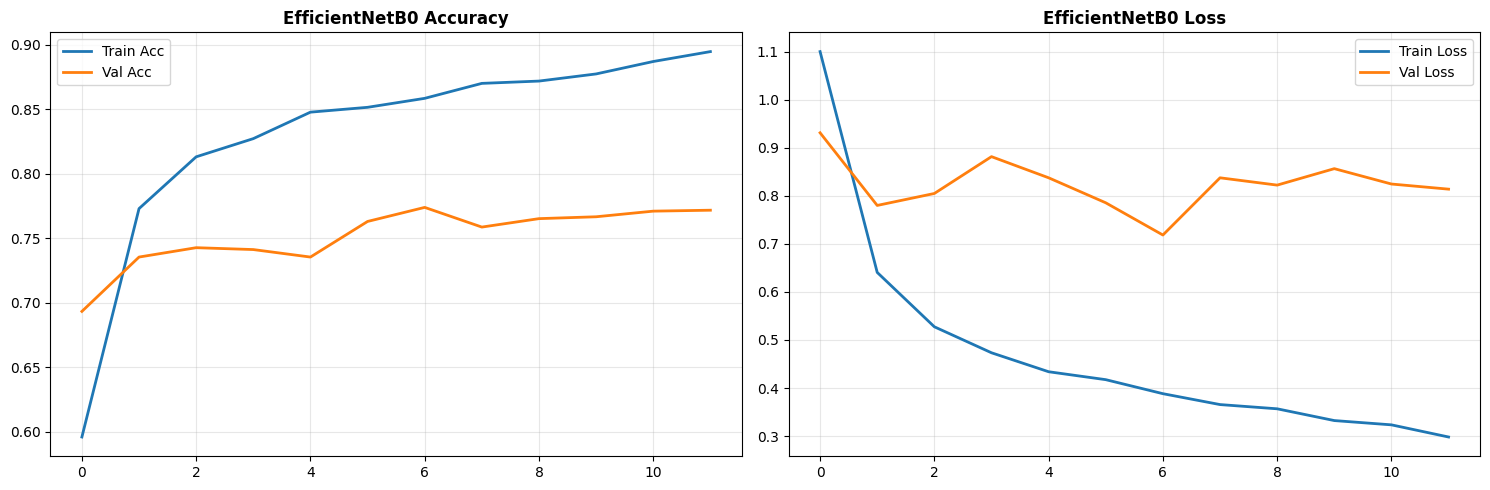


=== TEST RESULTS ===
67/67 ━━━━━━━━━━━━━━━━━━━━ 22s 331ms/step - accuracy: 0.9102 - loss: 0.2751
Test Accuracy: 0.9102
67/67 ━━━━━━━━━━━━━━━━━━━━ 24s 264ms/step

Classification Report:
                         precision    recall  f1-score   support

       Bacterial Blight       0.89      0.80      0.84       250
             Curl Virus       0.94      0.91      0.93       431
           Healthy Leaf       0.86      0.98      0.92       257
Herbicide Growth Damage       1.00      0.95      0.98       280
    Leaf Hopper Jassids       0.73      0.96      0.83       225
           Leaf Redding       0.98      0.86      0.92       578
       Leaf Variegation       0.94      1.00      0.97       116

               accuracy                           0.91      2137
              macro avg       0.90      0.93      0.91      2137
           weighted avg       0.92      0.91      0.91      2137



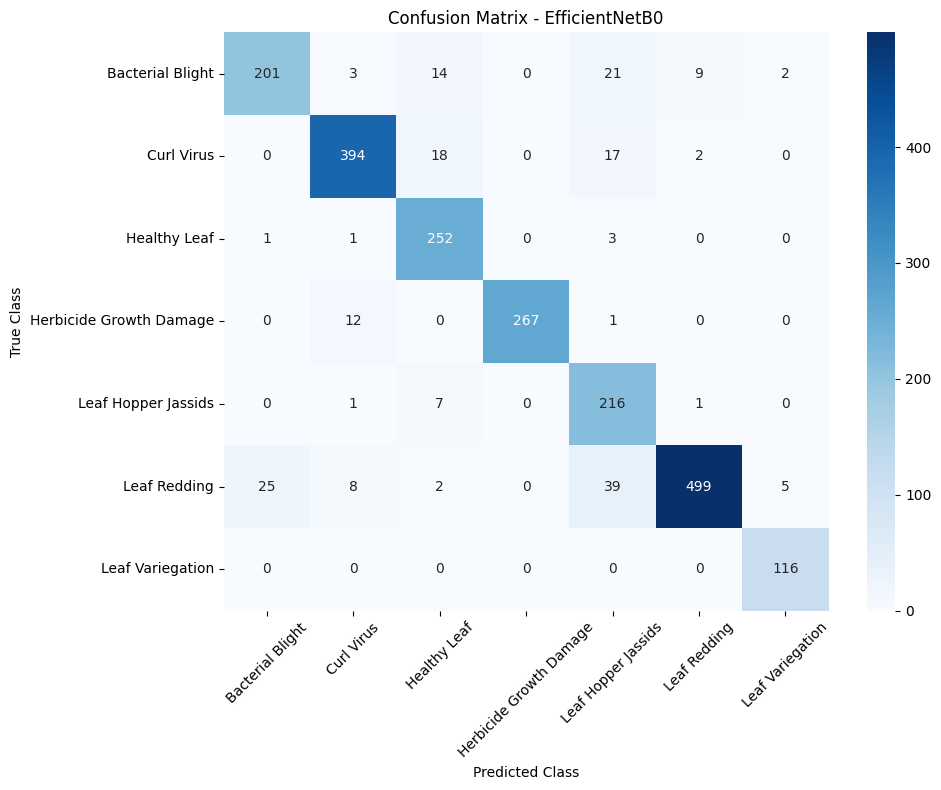


✅ COMPLETE! Model saved as 'cotton_disease_final.keras'.


In [8]:
# Plotting function
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy Plot
    ax1.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Acc', linewidth=2)
    ax1.set_title('EfficientNetB0 Accuracy', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss Plot
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    ax2.set_title('EfficientNetB0 Loss', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Run the plotting function
plot_training_history(history)

# Test evaluation
print("\n=== TEST RESULTS ===")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"Test Accuracy: {test_acc:.4f}")

# Classification report & confusion matrix
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_names))

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - EfficientNetB0')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Save final model using the updated standard Keras format
model.save('cotton_disease_final.keras')
print("\n✅ COMPLETE! Model saved as 'cotton_disease_final.keras'.")

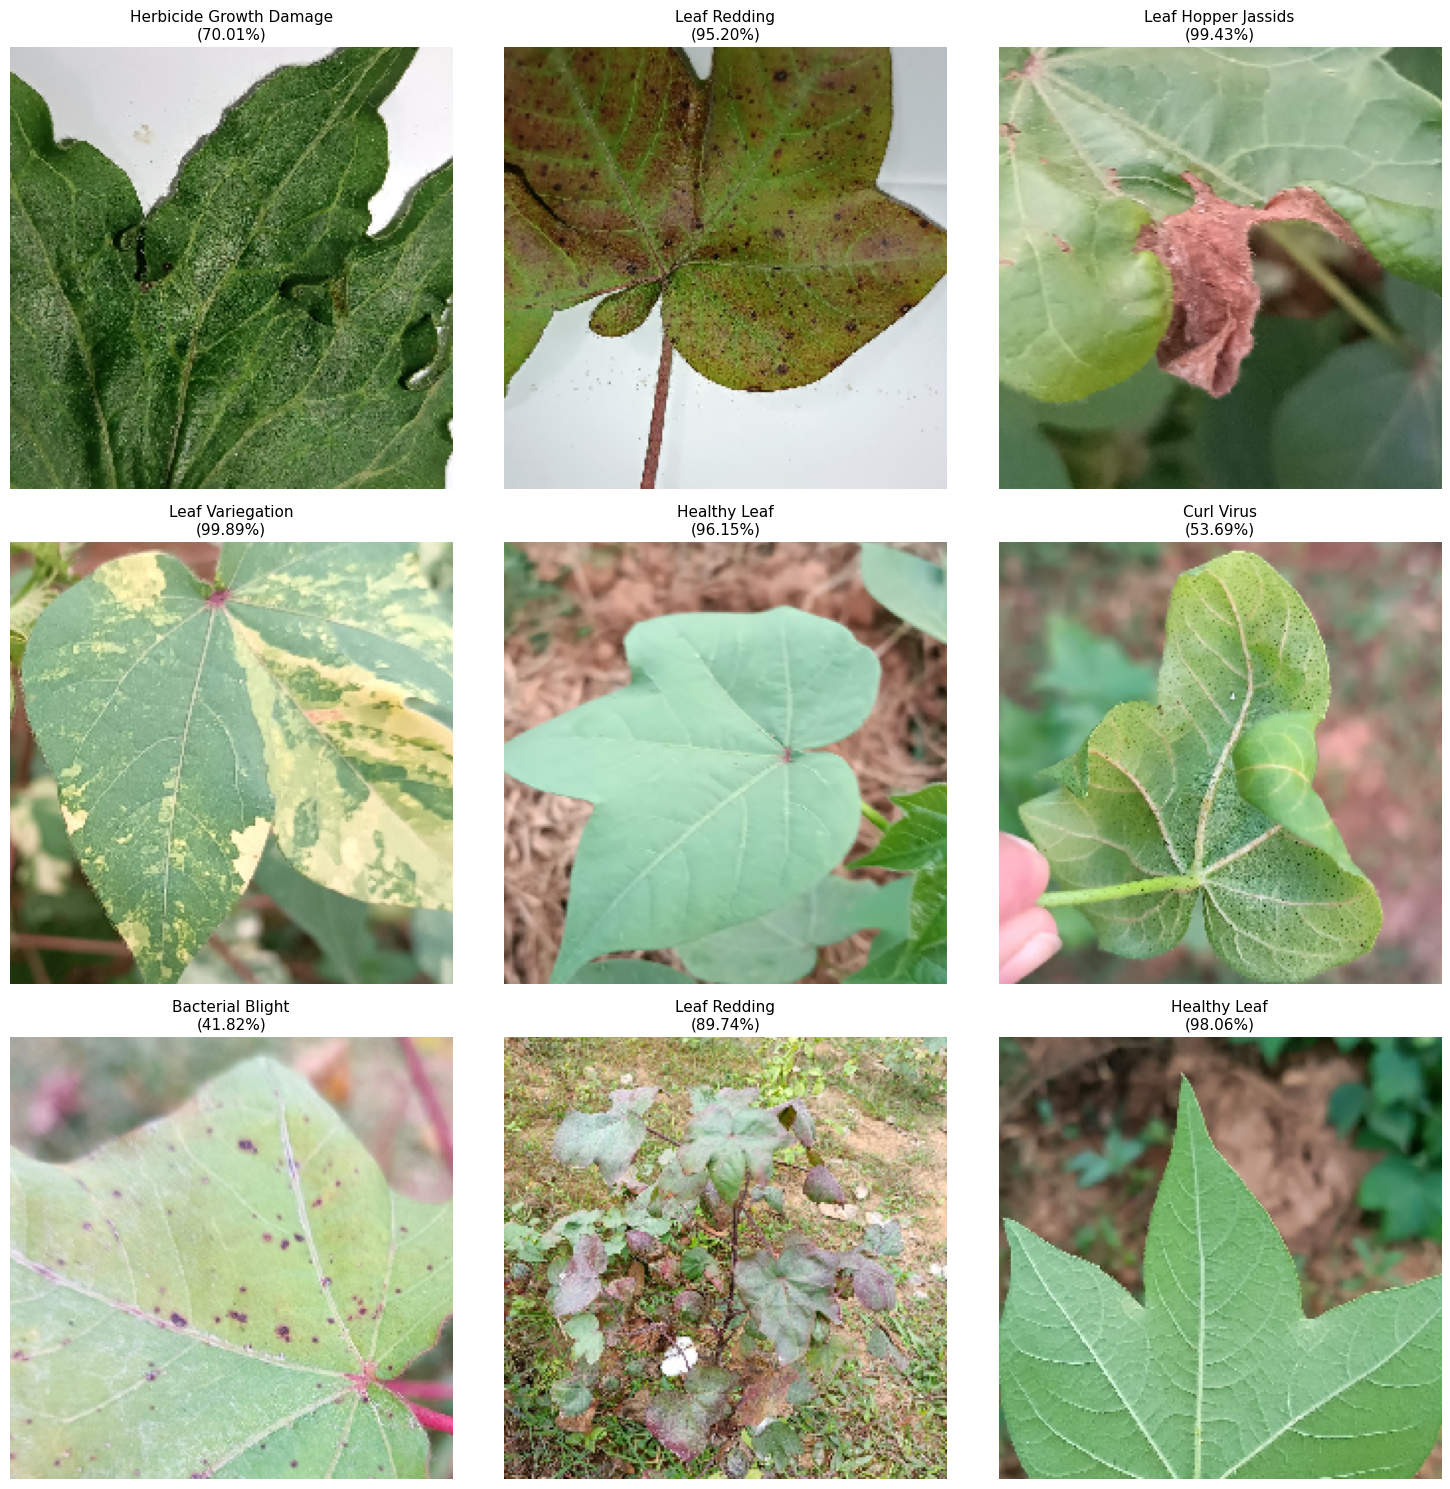

Prediction functions are ready to use!


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import random

# Load your trained model (Updated to modern standard Keras extension)
model = load_model('best_cotton_model.keras')

# =====================================================================
# UPDATED CLASS NAMES FOR THE NEW DATASET
# =====================================================================
class_names = [
    'Bacterial Blight',
    'Curl Virus',
    'Healthy Leaf',
    'Herbicide Growth Damage',
    'Leaf Hopper Jassids',
    'Leaf Redding',
    'Leaf Variegation'
]

# Function to predict and display an image
def predict_and_display(img_path, model, class_names):
    # Load and preprocess the image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # ⚠️ CRITICAL FOR EFFICIENTNET:
    # Do NOT divide by 255.0. EfficientNet expects raw [0-255] pixels.

    # Make prediction
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    # Get all class probabilities
    class_probabilities = {class_names[i]: float(prediction[0][i]) for i in range(len(class_names))}

    # Sort by probability
    sorted_probs = dict(sorted(class_probabilities.items(), key=lambda item: item[1], reverse=True))

    # Display the image with prediction
    plt.figure(figsize=(10, 8))

    # Show image
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.title(f'EfficientNet Prediction: {class_names[predicted_class]} (Confidence: {confidence:.2%})')
    plt.axis('off')

    # Show probabilities as bar chart
    plt.subplot(2, 1, 2)
    colors = ['green' if c == class_names[predicted_class] else 'blue' for c in sorted_probs.keys()]
    plt.barh(range(len(sorted_probs)), list(sorted_probs.values()), color=colors)
    plt.yticks(range(len(sorted_probs)), list(sorted_probs.keys()))
    plt.xlabel('Probability')
    plt.title('Class Probabilities')
    plt.gca().invert_yaxis()  # Invert y-axis to keep highest probability on top
    plt.tight_layout()
    plt.show()

    return class_names[predicted_class], confidence, class_probabilities

# Function to display multiple predictions in a grid
def display_predictions_grid(image_paths, model, class_names, grid_size=(3, 3)):
    fig, axes = plt.subplots(grid_size[0], grid_size[1], figsize=(15, 15))
    axes = axes.ravel()

    for i, img_path in enumerate(image_paths[:grid_size[0]*grid_size[1]]):
        # Load and preprocess the image
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        # ⚠️ CRITICAL FOR EFFICIENTNET: Do NOT divide by 255.0 here either

        # Make prediction
        prediction = model.predict(img_array, verbose=0)
        predicted_class = np.argmax(prediction[0])
        confidence = np.max(prediction[0])

        # Display the image with prediction
        axes[i].imshow(img)
        axes[i].set_title(f'{class_names[predicted_class]}\n({confidence:.2%})', fontsize=11)
        axes[i].axis('off')

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Function to get random samples from a directory
def get_random_samples(directory, num_samples=9):
    all_images = []
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_images.append(os.path.join(root, file))

    return random.sample(all_images, min(num_samples, len(all_images)))

# Example usage
if __name__ == "__main__":
    # =====================================================================
    # UPDATED SAMPLE DIRECTORY
    # =====================================================================
    sample_directory = os.path.join(
        "SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection",
        "Original Dataset",
        "Original Dataset"
    )

    # Alternative context: If testing single images explicitly, uncomment below lines
    # test_image_path = "path_to_some_leaf_image.jpg"
    # predict_and_display(test_image_path, model, class_names)

    # Option: Display multiple random images from the dataset in a grid
    if os.path.exists(sample_directory):
        sample_images = get_random_samples(sample_directory, 9)
        display_predictions_grid(sample_images, model, class_names, grid_size=(3, 3))
    else:
        print(f"⚠️ Directory not found at: {sample_directory}. Please double check path configurations.")

    print("Prediction functions are ready to use!")

Generating predictions from EfficientNet...
67/67 ━━━━━━━━━━━━━━━━━━━━ 25s 267ms/step
Total test samples: 2137
Misclassified samples: 192
Accuracy: 91.02%


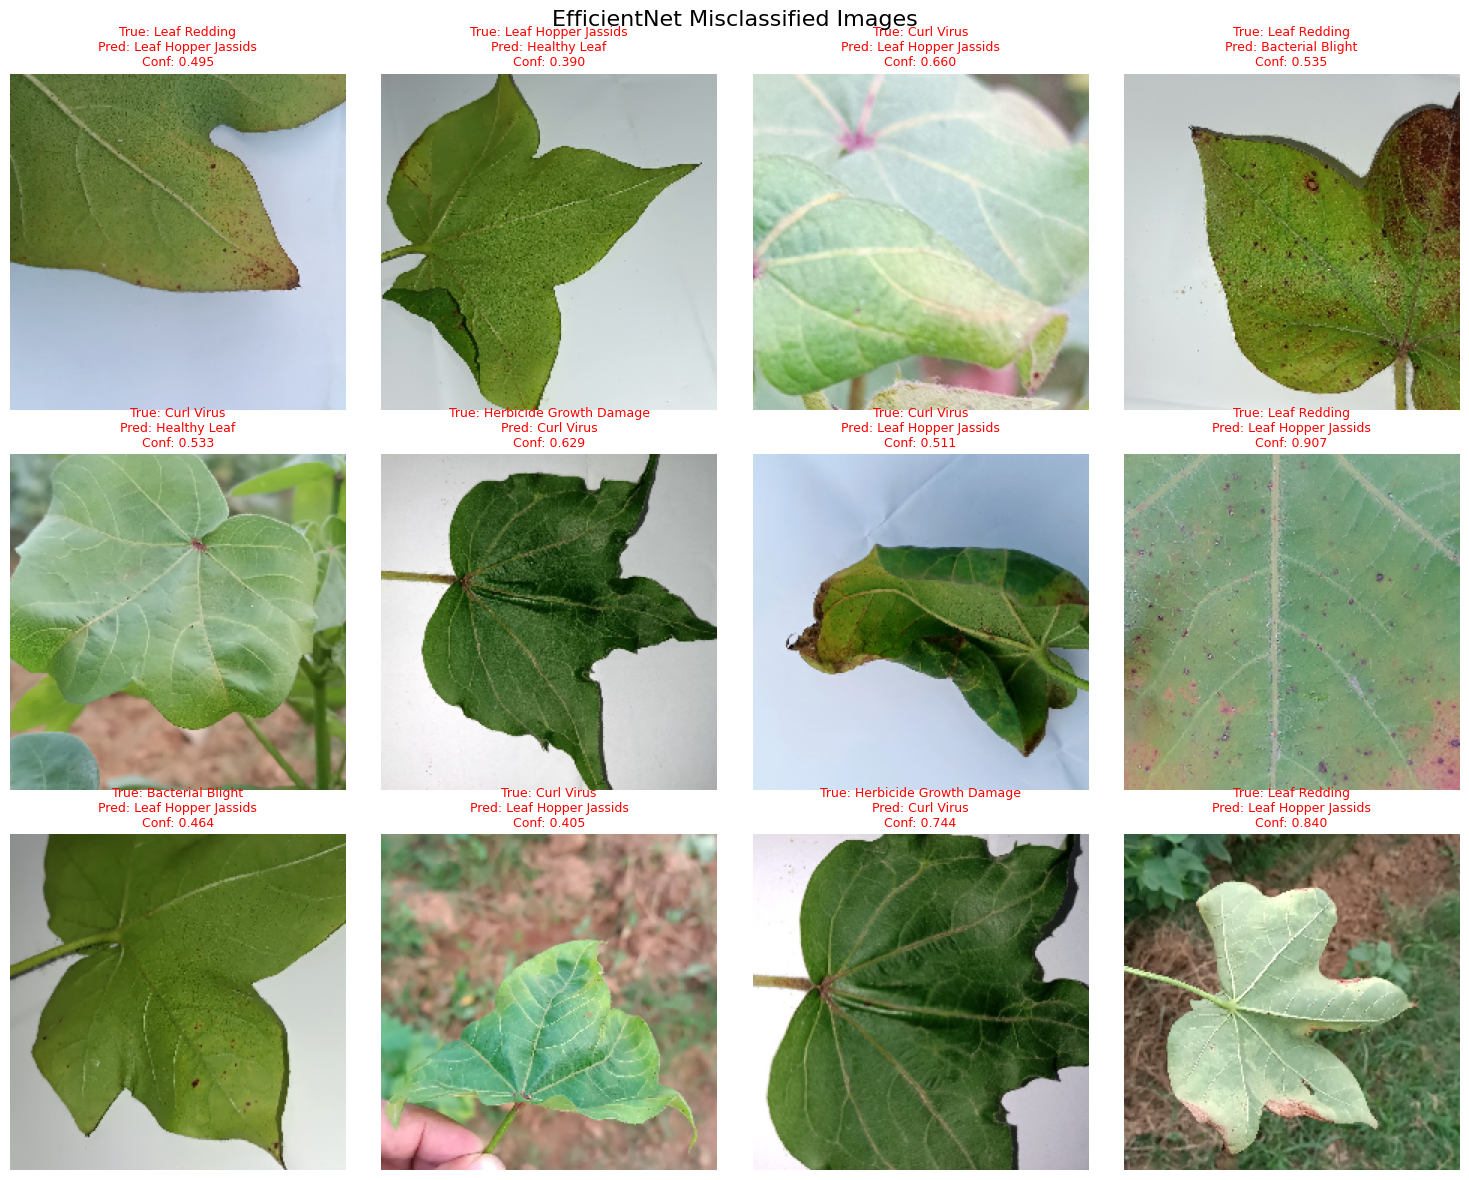


Error Rate by Class:
                     Class  Total Samples  Misclassifications  Error Rate
0         Bacterial Blight            250                  49   19.600000
5             Leaf Redding            578                  79   13.667820
1               Curl Virus            431                  37    8.584687
3  Herbicide Growth Damage            280                  13    4.642857
4      Leaf Hopper Jassids            225                   9    4.000000
2             Healthy Leaf            257                   5    1.945525
6         Leaf Variegation            116                   0    0.000000


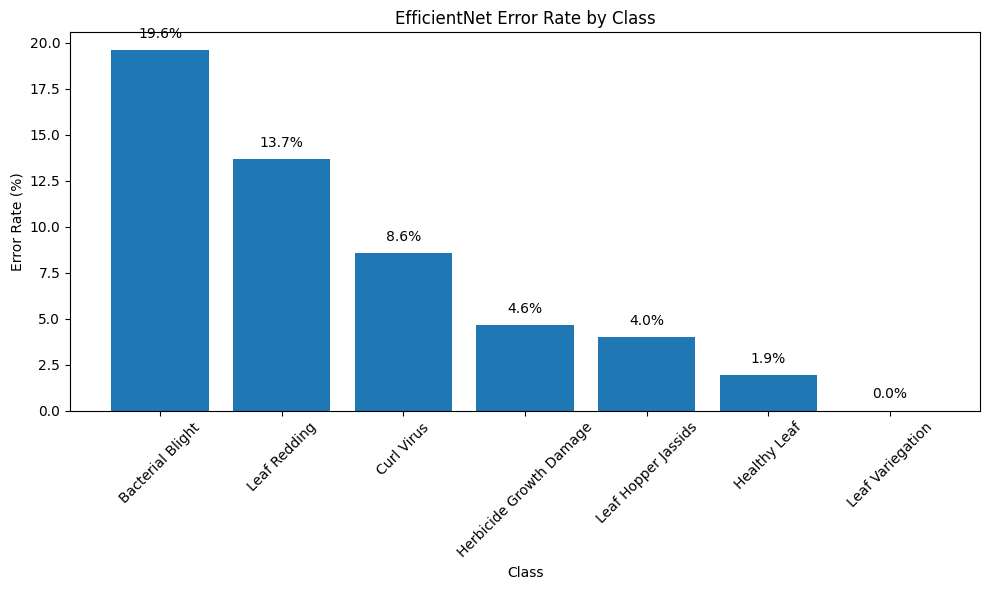


Most Common Misclassification Patterns:
                 true_label      predicted_label  count
19             Leaf Redding  Leaf Hopper Jassids     39
16             Leaf Redding     Bacterial Blight     25
2          Bacterial Blight  Leaf Hopper Jassids     21
5                Curl Virus         Healthy Leaf     18
6                Curl Virus  Leaf Hopper Jassids     17
1          Bacterial Blight         Healthy Leaf     14
11  Herbicide Growth Damage           Curl Virus     12
3          Bacterial Blight         Leaf Redding      9
17             Leaf Redding           Curl Virus      8
14      Leaf Hopper Jassids         Healthy Leaf      7


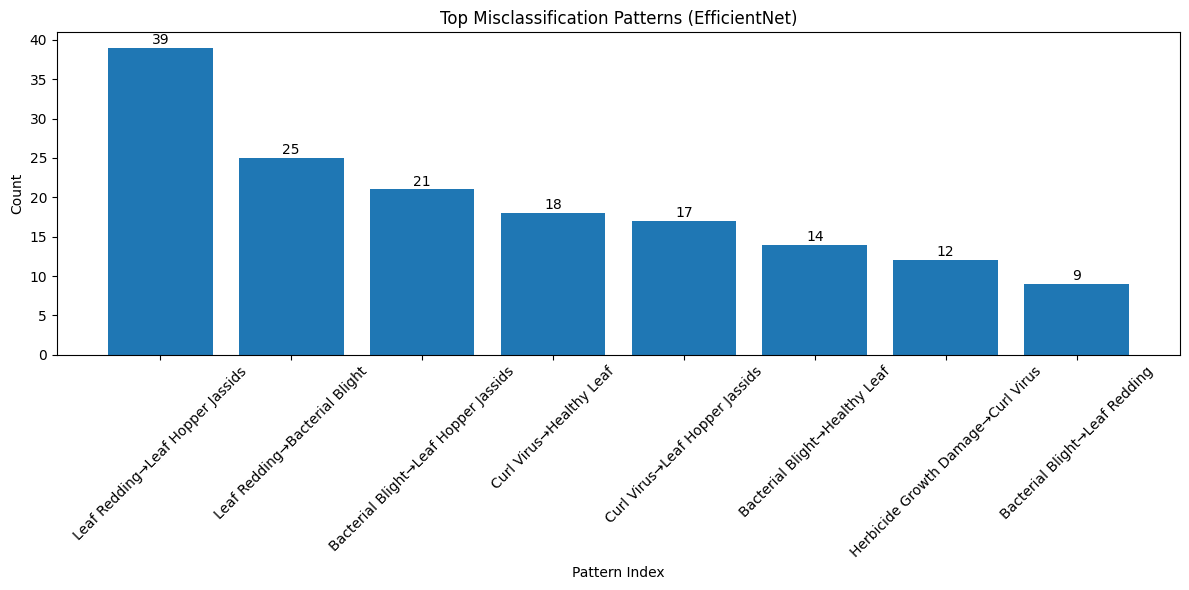

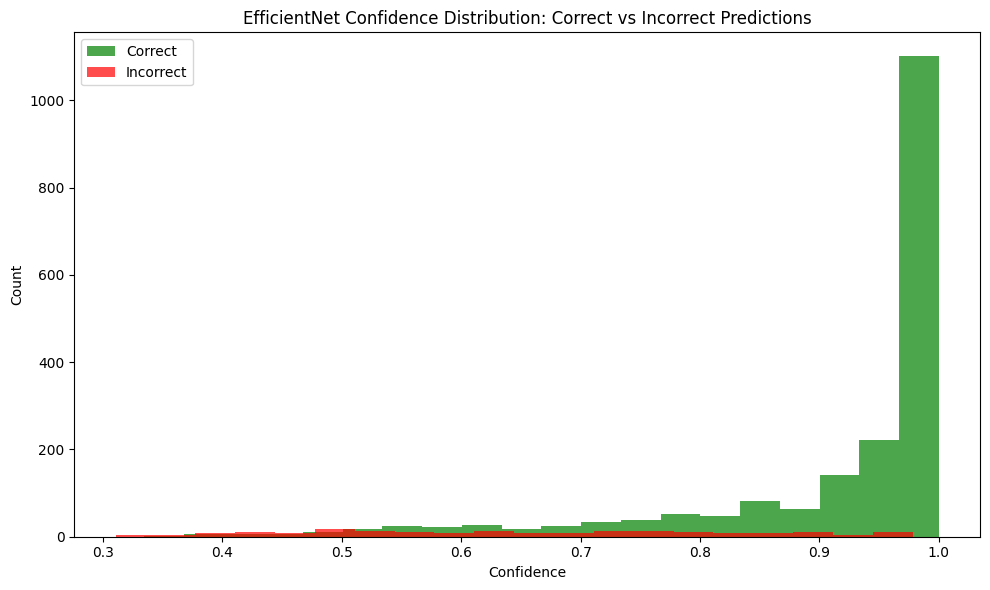


Confidence Statistics:
   correct      mean    median       std
0    False  0.649954  0.636795  0.177416
1     True  0.917448  0.977929  0.128694

High-confidence errors (confidence > 0.8): 47
These cases represent potentially serious model errors:
  Bacterial Blight/BBC00001.jpg: True=Bacterial Blight, Pred=Leaf Hopper Jassids, Conf=0.819
  Bacterial Blight/BBC00008.jpg: True=Bacterial Blight, Pred=Leaf Hopper Jassids, Conf=0.885
  Bacterial Blight/BBC00014.jpg: True=Bacterial Blight, Pred=Leaf Redding, Conf=0.849
  Bacterial Blight/BBC00066.jpg: True=Bacterial Blight, Pred=Leaf Redding, Conf=0.877
  Bacterial Blight/BBC00138.jpg: True=Bacterial Blight, Pred=Healthy Leaf, Conf=0.843
  Bacterial Blight/BBC00179.jpg: True=Bacterial Blight, Pred=Leaf Hopper Jassids, Conf=0.801
  Bacterial Blight/BBC00213.jpg: True=Bacterial Blight, Pred=Healthy Leaf, Conf=0.873
  Curl Virus/CV00018.jpg: True=Curl Virus, Pred=Healthy Leaf, Conf=0.922
  Curl Virus/CV00019.jpg: True=Curl Virus, Pred=Health

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from tensorflow.keras.preprocessing import image
import seaborn as sns

# =====================================================================
# PATH CONFIGURATION MATCHING PREVIOUS STEP
# =====================================================================
base_dataset_path = "SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection"
original_path = os.path.join(base_dataset_path, "Original Dataset", "Original Dataset")

# Get predictions and true labels for the test set
# ⚠️ CRITICAL: Removed test_generator.reset() to prevent mismatch issues in modern Keras.
print("Generating predictions from EfficientNet...")
y_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_probs, axis=1)
y_true = test_generator.classes

# Get filenames for the test set
filenames = test_generator.filenames

# Create a DataFrame for analysis
results_df = pd.DataFrame({
    'filename': filenames,
    'true_label': [class_names[i] for i in y_true],
    'predicted_label': [class_names[i] for i in y_pred],
    'confidence': [np.max(y_probs[i]) for i in range(len(y_probs))],
    'correct': y_true == y_pred
})

# Filter misclassified images
misclassified_df = results_df[results_df['correct'] == False]

print(f"Total test samples: {len(results_df)}")
print(f"Misclassified samples: {len(misclassified_df)}")
print(f"Accuracy: {(len(results_df) - len(misclassified_df)) / len(results_df) * 100:.2f}%")


# 1. Display misclassified images with predictions and confidence
def display_misclassified_images(misclassified_df, num_samples=12):
    if len(misclassified_df) == 0:
        print("🎉 No misclassifications found to display!")
        return

    # Randomly select misclassified samples
    samples = misclassified_df.sample(min(num_samples, len(misclassified_df)))

    # Create a grid of images
    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.ravel()

    for i, (idx, row) in enumerate(samples.iterrows()):
        # UPDATED PATH: Pointing directly into the raw original test baseline folders
        img_path = os.path.join(original_path, row['filename'])
        img = image.load_img(img_path, target_size=(224, 224))

        axes[i].imshow(img)
        axes[i].set_title(f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.3f}",
                          fontsize=9, color='red')
        axes[i].axis('off')

    # Clear any leftover subplots if there are fewer errors than slots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle('EfficientNet Misclassified Images', fontsize=16)
    plt.tight_layout()
    plt.savefig('efficientnet_misclassified_images.png')
    plt.show()

display_misclassified_images(misclassified_df)


# 2. Analyze misclassifications by class
misclassification_by_class = results_df.groupby('true_label').agg({
    'correct': ['count', lambda x: sum(x == False)]
}).reset_index()
misclassification_by_class.columns = ['Class', 'Total Samples', 'Misclassifications']
misclassification_by_class['Error Rate'] = misclassification_by_class['Misclassifications'] / misclassification_by_class['Total Samples'] * 100
misclassification_by_class = misclassification_by_class.sort_values('Error Rate', ascending=False)

print("\nError Rate by Class:")
print(misclassification_by_class)

# Plot error rates by class
plt.figure(figsize=(10, 6))
bars = plt.bar(misclassification_by_class['Class'], misclassification_by_class['Error Rate'])
plt.title('EfficientNet Error Rate by Class')
plt.xlabel('Class')
plt.ylabel('Error Rate (%)')
plt.xticks(rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('efficientnet_error_rate_by_class.png')
plt.show()


# 3. Most common misclassification patterns
misclassification_patterns = results_df[results_df['correct'] == False].groupby(
    ['true_label', 'predicted_label']).size().reset_index(name='count')
misclassification_patterns = misclassification_patterns.sort_values('count', ascending=False)

print("\nMost Common Misclassification Patterns:")
print(misclassification_patterns.head(10))

# Visualize common misclassification patterns
if len(misclassification_patterns) > 0:
    plt.figure(figsize=(12, 6))
    top_patterns = misclassification_patterns.head(8)
    bars = plt.bar(range(len(top_patterns)), top_patterns['count'])
    plt.title('Top Misclassification Patterns (EfficientNet)')
    plt.xlabel('Pattern Index')
    plt.ylabel('Count')
    plt.xticks(range(len(top_patterns)),
               [f"{row['true_label']}→{row['predicted_label']}" for _, row in top_patterns.iterrows()],
               rotation=45)

    # Add value labels on bars
    for bar, count in zip(bars, top_patterns['count']):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                 str(count), ha='center', va='bottom')
    plt.tight_layout()
    plt.savefig('efficientnet_top_misclassification_patterns.png')
    plt.show()


# 4. Analyze confidence of misclassifications vs correct classifications
plt.figure(figsize=(10, 6))
plt.hist(results_df[results_df['correct'] == True]['confidence'],
         alpha=0.7, label='Correct', bins=20, color='green')
plt.hist(results_df[results_df['correct'] == False]['confidence'],
         alpha=0.7, label='Incorrect', bins=20, color='red')
plt.title('EfficientNet Confidence Distribution: Correct vs Incorrect Predictions')
plt.xlabel('Confidence')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('efficientnet_confidence_distribution.png')
plt.show()


# 5. Analyze confidence statistics
confidence_stats = results_df.groupby('correct')['confidence'].agg(['mean', 'median', 'std']).reset_index()
print("\nConfidence Statistics:")
print(confidence_stats)


# 6. Examine high-confidence errors (potentially problematic cases)
high_confidence_errors = misclassified_df[misclassified_df['confidence'] > 0.8]
print(f"\nHigh-confidence errors (confidence > 0.8): {len(high_confidence_errors)}")
if len(high_confidence_errors) > 0:
    print("These cases represent potentially serious model errors:")
    for _, row in high_confidence_errors.iterrows():
        print(f"  {row['filename']}: True={row['true_label']}, Pred={row['predicted_label']}, Conf={row['confidence']:.3f}")


# 7. Examine low-confidence correct predictions (potentially lucky guesses)
low_confidence_correct = results_df[(results_df['correct'] == True) & (results_df['confidence'] < 0.6)]
print(f"\nLow-confidence correct predictions (confidence < 0.6): {len(low_confidence_correct)}")


# 8. Generate a detailed error analysis report
def generate_error_report(results_df, misclassification_patterns, misclassified_df):
    report = {
        'total_samples': len(results_df),
        'misclassified_samples': len(misclassified_df),
        'overall_accuracy': (len(results_df) - len(misclassified_df)) / len(results_df) * 100,
        'class_wise_error_rates': misclassification_by_class.to_dict('records'),
        'common_misclassification_patterns': misclassification_patterns.head(10).to_dict('records'),
        'average_confidence_correct': results_df[results_df['correct'] == True]['confidence'].mean(),
        'average_confidence_incorrect': results_df[results_df['correct'] == False]['confidence'].mean(),
        'high_confidence_errors': len(misclassified_df[misclassified_df['confidence'] > 0.8]),
        'low_confidence_correct': len(results_df[(results_df['correct'] == True) & (results_df['confidence'] < 0.6)])
    }

    # Save report
    with open('efficientnet_error_analysis_report.txt', 'w') as f:
        f.write("EFFICIENTNET COTTON DISEASE CLASSIFICATION ERROR ANALYSIS REPORT\n")
        f.write("===============================================================\n\n")
        f.write(f"Overall Accuracy: {report['overall_accuracy']:.2f}%\n")
        f.write(f"Misclassified Samples: {report['misclassified_samples']}/{report['total_samples']}\n\n")

        f.write("Class-wise Error Rates:\n")
        for item in report['class_wise_error_rates']:
            f.write(f"{item['Class']}: {item['Error Rate']:.2f}% ({item['Misclassifications']}/{item['Total Samples']})\n")

        f.write("\nMost Common Misclassification Patterns:\n")
        for item in report['common_misclassification_patterns']:
            f.write(f"{item['true_label']} -> {item['predicted_label']}: {item['count']} times\n")

        f.write(f"\nAverage Confidence for Correct Predictions: {report['average_confidence_correct']:.3f}\n")
        f.write(f"Average Confidence for Incorrect Predictions: {report['average_confidence_incorrect']:.3f}\n")
        f.write(f"High-confidence Errors (confidence > 0.8): {report['high_confidence_errors']}\n")
        f.write(f"Low-confidence Correct Predictions (confidence < 0.6): {report['low_confidence_correct']}\n")

    return report

error_report = generate_error_report(results_df, misclassification_patterns, misclassified_df)
print("\nError analysis completed. Check the generated images and 'efficientnet_error_analysis_report.txt' for insights.")

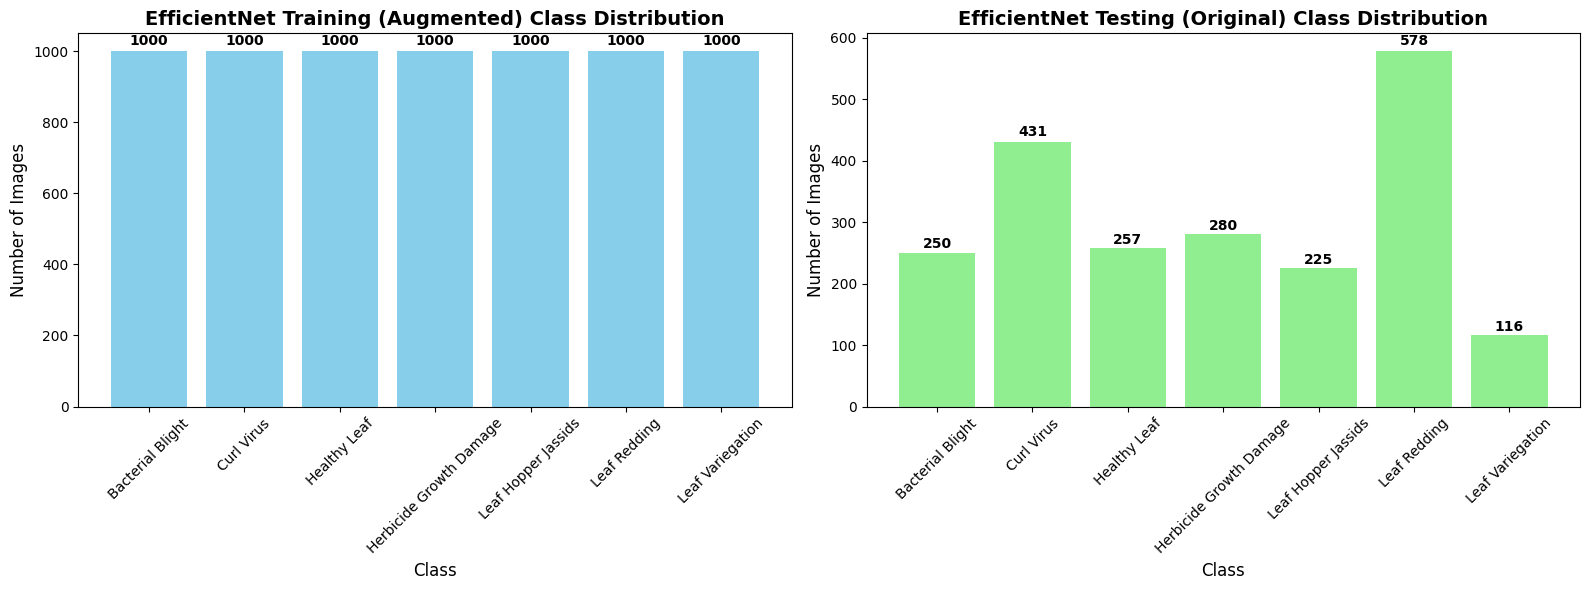

EFFICIENTNET PIPELINE: DATASET CLASS DISTRIBUTION SUMMARY

Training Dataset (Augmented Dataset) Class Distribution:
  Bacterial Blight: 1000 images
  Curl Virus: 1000 images
  Healthy Leaf: 1000 images
  Herbicide Growth Damage: 1000 images
  Leaf Hopper Jassids: 1000 images
  Leaf Redding: 1000 images
  Leaf Variegation: 1000 images

Testing Dataset (Original Dataset) Class Distribution:
  Bacterial Blight: 250 images
  Curl Virus: 431 images
  Healthy Leaf: 257 images
  Herbicide Growth Damage: 280 images
  Leaf Hopper Jassids: 225 images
  Leaf Redding: 578 images
  Leaf Variegation: 116 images

Total training images: 7000
Total testing images: 2137
Total images across both datasets: 9137

CLASS BALANCE ANALYSIS

Training Dataset Class Balance:
  Bacterial Blight: 1000 images (14.3%)
  Curl Virus: 1000 images (14.3%)
  Healthy Leaf: 1000 images (14.3%)
  Herbicide Growth Damage: 1000 images (14.3%)
  Leaf Hopper Jassids: 1000 images (14.3%)
  Leaf Redding: 1000 images (14.3%)
  Leaf

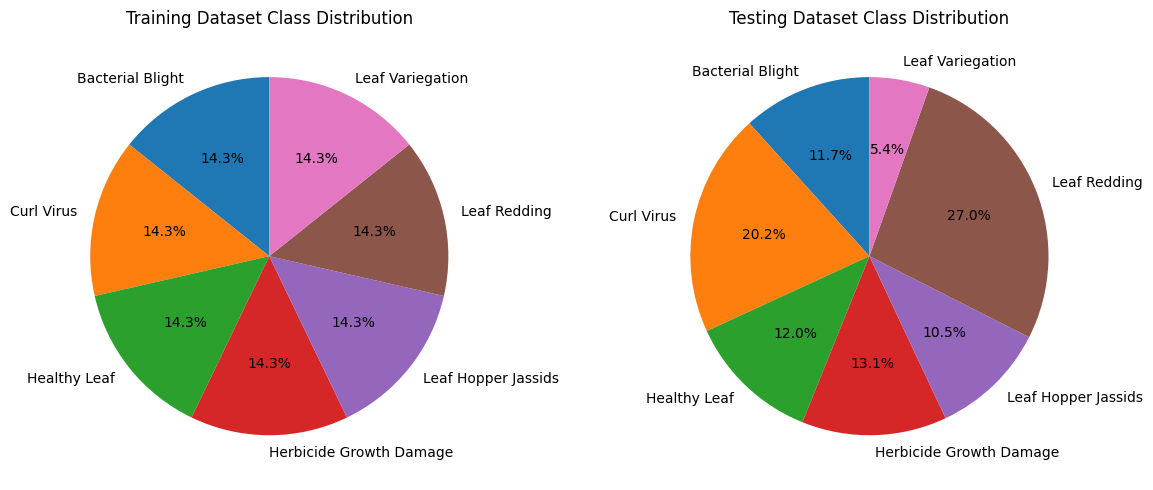


CLASS DISTRIBUTION COMPARISON TABLE
Class                Train Count  Test Count   Total      Train %    Test %    
--------------------------------------------------------------------------------
Bacterial Blight     1000         250          1250       14.3%      11.7%     
Curl Virus           1000         431          1431       14.3%      20.2%     
Healthy Leaf         1000         257          1257       14.3%      12.0%     
Herbicide Growth Damage 1000         280          1280       14.3%      13.1%     
Leaf Hopper Jassids  1000         225          1225       14.3%      10.5%     
Leaf Redding         1000         578          1578       14.3%      27.0%     
Leaf Variegation     1000         116          1116       14.3%      5.4%      


In [11]:
import matplotlib.pyplot as plt
import numpy as np
import os

# =====================================================================
# PATH CONFIGURATION MATCHING THE NEW DATASET STRUCTURE
# =====================================================================
base_dataset_path = "SAR-CLD-2024 A Comprehensive Dataset for Cotton Leaf Disease Detection"
augmented_path = os.path.join(base_dataset_path, "Augmented Dataset", "Augmented Dataset")
original_path = os.path.join(base_dataset_path, "Original Dataset", "Original Dataset")

# Define the exact 7 classes present in this dataset
class_names = [
    'Bacterial Blight',
    'Curl Virus',
    'Healthy Leaf',
    'Herbicide Growth Damage',
    'Leaf Hopper Jassids',
    'Leaf Redding',
    'Leaf Variegation'
]

# Get class distribution for training dataset (Augmented Dataset folder)
train_class_counts = {}
for class_name in class_names:
    class_dir = os.path.join(augmented_path, class_name)
    if os.path.exists(class_dir):
        train_class_counts[class_name] = len(os.listdir(class_dir))
    else:
        train_class_counts[class_name] = 0

# Get class distribution for testing dataset (Original Dataset folder)
test_class_counts = {}
for class_name in class_names:
    class_dir = os.path.join(original_path, class_name)
    if os.path.exists(class_dir):
        test_class_counts[class_name] = len(os.listdir(class_dir))
    else:
        test_class_counts[class_name] = 0

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot training dataset class distribution
bars1 = ax1.bar(train_class_counts.keys(), train_class_counts.values(), color='skyblue')
ax1.set_title('EfficientNet Training (Augmented) Class Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Number of Images', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Add value labels on bars for training dataset
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + max(1, height * 0.01),
             f'{height}', ha='center', va='bottom', fontweight='bold')

# Plot testing dataset class distribution
bars2 = ax2.bar(test_class_counts.keys(), test_class_counts.values(), color='lightgreen')
ax2.set_title('EfficientNet Testing (Original) Class Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Class', fontsize=12)
ax2.set_ylabel('Number of Images', fontsize=12)
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars for testing dataset
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + max(1, height * 0.01),
             f'{height}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
# Updated filename to separate your EfficientNet workspace artifacts
plt.savefig('efficientnet_dataset_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print numerical summary
print("="*60)
print("EFFICIENTNET PIPELINE: DATASET CLASS DISTRIBUTION SUMMARY")
print("="*60)

print("\nTraining Dataset (Augmented Dataset) Class Distribution:")
for class_name, count in train_class_counts.items():
    print(f"  {class_name}: {count} images")

print("\nTesting Dataset (Original Dataset) Class Distribution:")
for class_name, count in test_class_counts.items():
    print(f"  {class_name}: {count} images")

total_train = sum(train_class_counts.values())
total_test = sum(test_class_counts.values())

print(f"\nTotal training images: {total_train}")
print(f"Total testing images: {total_test}")
print(f"Total images across both datasets: {total_train + total_test}")

# Calculate and display class balance percentages
print("\n" + "="*60)
print("CLASS BALANCE ANALYSIS")
print("="*60)

print("\nTraining Dataset Class Balance:")
for class_name, count in train_class_counts.items():
    percentage = (count / total_train) * 100 if total_train > 0 else 0
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

print("\nTesting Dataset Class Balance:")
for class_name, count in test_class_counts.items():
    percentage = (count / total_test) * 100 if total_test > 0 else 0
    print(f"  {class_name}: {count} images ({percentage:.1f}%)")

# Create a pie chart for dataset class distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
if total_train > 0:
    plt.pie(train_class_counts.values(), labels=train_class_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Training Dataset Class Distribution')

plt.subplot(1, 2, 2)
if total_test > 0:
    plt.pie(test_class_counts.values(), labels=test_class_counts.keys(), autopct='%1.1f%%', startangle=90)
plt.title('Testing Dataset Class Distribution')

plt.tight_layout()
# Updated filename to keep results isolated
plt.savefig('efficientnet_dataset_class_pie_charts.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a comparison table
comparison_data = []
for class_name in class_names:
    train_count = train_class_counts[class_name]
    test_count = test_class_counts[class_name]
    total_count = train_count + test_count
    train_percentage = (train_count / total_train) * 100 if total_train > 0 else 0
    test_percentage = (test_count / total_test) * 100 if total_test > 0 else 0
    comparison_data.append([class_name, train_count, test_count, total_count, f"{train_percentage:.1f}%", f"{test_percentage:.1f}%"])

# Display comparison table
print("\n" + "="*80)
print("CLASS DISTRIBUTION COMPARISON TABLE")
print("="*80)
print(f"{'Class':<20} {'Train Count':<12} {'Test Count':<12} {'Total':<10} {'Train %':<10} {'Test %':<10}")
print("-"*80)
for row in comparison_data:
    print(f"{row[0]:<20} {row[1]:<12} {row[2]:<12} {row[3]:<10} {row[4]:<10} {row[5]:<10}")